# 🌌 Professional Plotting: Crafting Publication-Ready Astronomy Figures with Matplotlib

Designed by Neil Ghugare.

___

## 📋 Table of Contents

| Section | Title | Description |
| :--- | :--- | :--- |
| **1** | **Introduction & Prerequisites** | Scope, expectations, and setup overview. |
| **2** | **Global Styling & `plt.rcParams`** | Configuring default fonts, sizes, and internal tick marks across entire sessions using Matplotlib's runtime configuration. |
| **3** | **LaTeX & Mathematical Notation** | Adding publication-standard typography, astronomical units, and math symbols to labels and annotations. |
| **4** | **Color Accessibility & CVD Safety** | Choosing perceptually uniform colormaps, designing for Color Vision Deficiency (CVD), and testing grayscale readability. |
| **5** | **Astronomical Plot Conventions** | Field-specific standards: inverted axes for magnitudes/CMDs, dual/secondary axes (e.g., wavelength vs. redshift), and image colorbars. |
| **6** | **Exporting & Journal Submission** | Column-width scaling, vector (`.pdf`) vs. raster (`.png`) formats, DPI settings, and selective rasterization for large datasets. |

___


## 1. Introduction & Prerequisites

Welcome! The goal of this tutorial notebook is to bridge the gap between functional Python plotting and creating polished, journal-quality figures for astronomical research (just the figures, figure captions are not discussed here) for astronomical research, thesis chapters, and professional presentations. 

> **⚠️ Prerequisite Warning:**
> 
> For this notebook, prerequisite knowledge in Python 3 is assumed, that the user has a working Python 3 environment, the user's environment has `matplotlib` and `numpy` installed, and the user knows how to use `matplotlib`. 
> 
> This notebook does **NOT** teach basic `matplotlib` syntax or general Python programming. It assumes you already know how to create basic line plots, scatter plots, and load data (e.g., using `numpy`, `astropy`, `pandas`, etc.). Our focus is strictly on **refining**, **styling**, and **formatting** figures to meet professional standards.

If your environment is set up properly, the following import should work without errors:

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Asserts the matplotlib version.
# If this fails, feel free to remove the "assert" line, but see the warning below.
import matplotlib as mpl
assert mpl.__version__ >= '3.10.9'

> **⚠️ Version Warning:**
> 
> This notebook was designed with a `matplotlib` version `>=3.10.9`. No guarantees are made about its functionality in older versions.

For this entire notebook, feel free to play around with the code so you get a good feeling about how things work and function, and how to make adjustments based on your own needs!

___

## 2. Global Styling & `plt.rcParams`

Instead of manually configuring fonts, line weights, and tick directions every single time you call `plt.plot()`, you can set a global design standard at the top of your script or notebook using `plt.rcParams`. 

Professional astronomy journals (like AAS and EDP Sciences) require:
- **Internal Ticks:** Ticks pointing inward so they don't get cut off or collide with neighboring subplots.
- **Ticks on all 4 sides:** Top, bottom, left, and right axes should have ticks for readability.
- **Legible Font Sizing:** Text must remain readable when a two-column figure is shrunk down to fit a single journal column (~3.3 inches wide).

The first thing I always recommend you do is reset the `matplotlib` parameters to the default parameters first. This is *optional* but it does ensure a clean state each time:

In [2]:
# Reset to default matplotlib style.
plt.rcParams.update(plt.rcParamsDefault)

To see what plots look like with default `matplotlib` styling, I have provided an example plot below:

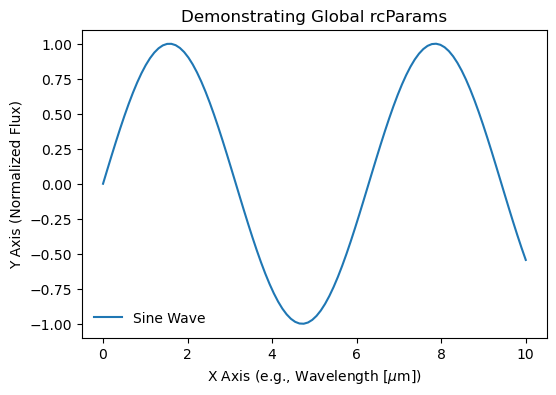

In [3]:
# Wenerate a quick dummy plot to showcase the default styling.
x = np.linspace(0, 10, 100)
y = np.sin(x)

# Create a figure and plot the sine wave.
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(x, y, label='Sine Wave')

ax.set_xlabel('X Axis (e.g., Wavelength [$\\mu$m])')
ax.set_ylabel('Y Axis (Normalized Flux)')
ax.set_title('Demonstrating Global rcParams')
ax.legend(frameon=False)

plt.show()

Now, we can make changes to `rcParams`. 

> **📝 Note:**
> 
> Updating `rcParams` will change features for **all** plots you make in a notebook or Python file. If there are aspects that will change plot to plot, it is **not** recommended to edit the `rcParams`.

Here is an example of an `rcParams` update, with changes that are common for plots in astronomy. There are many more options, which can be found on [`matplotlib`'s documentation.](https://matplotlib.org/stable/users/explain/configuration.html) You might need to edit these depending on your styling preferences and what plotting requirements might be required of you.

In [4]:
# Apply professional astronomy styling rcParams.
plt.rcParams.update({
    # Typography & fonts
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans', 'Helvetica', 'Arial'],
    'font.size': 11,                # Font sizing.
    'axes.labelsize': 13,           # Axes label sizes.
    'axes.titlesize': 14,           # Axes title sizes.
    'xtick.labelsize': 11,          # x-ticks label sizes.
    'ytick.labelsize': 11,          # y-ticks label sizes.
    'legend.fontsize': 11,          # Legend font size.
    
    # Line and marker weights.
    'lines.linewidth': 1.5,         # Default line width.
    'patch.linewidth': 1.0,         # Patch line width.
    'axes.linewidth': 1.0,          # Axes line width.
    
    # Ticks: Internal direction and visible on all 4 sides.
    'xtick.direction': 'in',        # Inward x-ticks.
    'ytick.direction': 'in',        # Inward y-ticks.
    'xtick.top': True,              # Ticks on top too.
    'ytick.right': True,            # Ticks on the right too.
    'xtick.minor.visible': True,    # Make minor x-ticks visible.
    'ytick.minor.visible': True,    # Make minor y-ticks visible.
    
    # Tick sizing & length.
    'xtick.major.size': 6.0,        # x-tick major size.
    'xtick.minor.size': 3.0,        # x-tick minor size.
    'ytick.major.size': 6.0,        # y-tick major size.
    'ytick.minor.size': 3.0,        # y-tick minor size.
    
    # Figure layout & saving options.
    'figure.dpi': 150,              # Screen display resolution.
    'savefig.dpi': 300,             # Print/publication export resolution.
    'savefig.bbox': 'tight',        # Prevents labels from getting clipped on save.

    # Grid styling.
    'axes.grid': True,              # Turn grids on globally.
    'grid.linestyle': '--',         # Dashed grid lines.
    'grid.alpha': 0.5,              # 50% transparency so they aren't distracting.
    'grid.color': 'gray',           # Soft gray color instead of harsh black.
    'grid.linewidth': 0.8,          # Thin lines.

})

print("Global RC parameters successfully updated for astronomy styling!")


Global RC parameters successfully updated for astronomy styling!


Now that our parameters are updated, let's take a peek at what the plot looks like now (it already looks much better)!

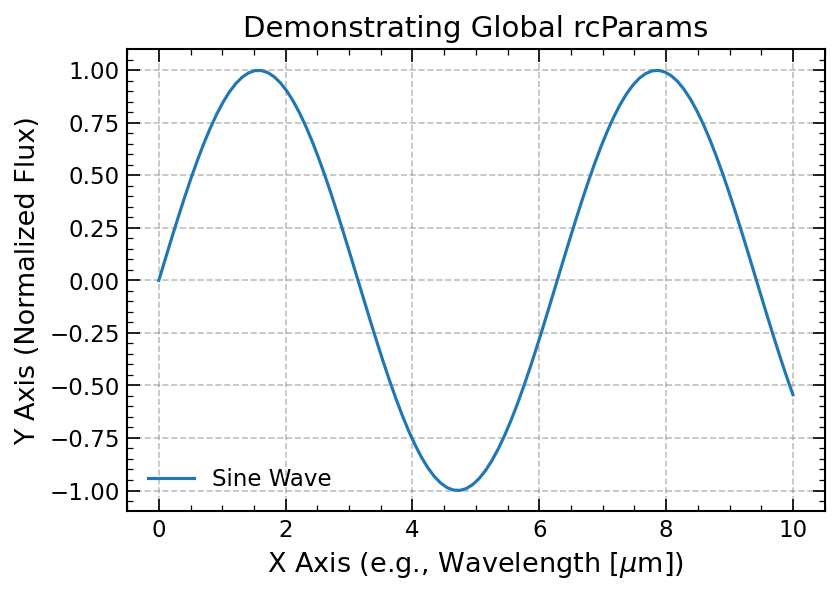

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(x, y, label='Sine Wave')

ax.set_xlabel('X Axis (e.g., Wavelength [$\\mu$m])')
ax.set_ylabel('Y Axis (Normalized Flux)')
ax.set_title('Demonstrating Global rcParams')
ax.legend(frameon=False)

plt.show()

Now these guidelines will always apply by default (so we don't need to use the `ax.grid` function to get a grid or set both ticks manually). This saves a lot of time and cleans up your code too!

___

## 3. LaTeX & Mathematical Notation in Astronomy

Astronomy plots are filled with complex units, Greek letters, subscripts, and symbols (e.g., $\lambda$, $F_\lambda$, $M_\odot$, $\log(L/L_\odot)$). 

Instead of typing out words like "alpha" or "Flux_lambda", we use **MathText**. It uses standard $\LaTeX$ syntax inside Python raw strings (`r'...'`) and works **completely out of the box** without needing a heavy local $\LaTeX$ installation.

> **📝 Note:**
>
> You can use your own $\LaTeX$ engine with `rcParams` by setting `'text.usetex'` to `True`. This, however, makes `matplotlib` spawn an external system compiler (`latex`, `dvipng`, etc.) to compile your text elements through a real $\LaTeX$ distribution. **This requires a full local $\LaTeX$ distribution (like TeX Live, MiKTeX, etc.)**. This could easily break if you don't have it, and is not necessary except for very specific styling requirements. For most purposes, MathText from `matplotlib` is sufficient. 


> **⚠️ Warning:**
> 
> Depending on your font choice and the symbols/packages you typically use, some $\LaTeX$ features may not be usable with MathText. However, most astronomical symbols and use cases function just fine.

Let's take a look at how to put $\LaTeX$ in the labels and titles of a plot. You can do this by using a python r-string (raw string), and using the typical inline $\LaTeX$ delimiter `$` (we can also see our styling still applies here!). The point of using a raw string is because backslashes in standard Python strings are typically for escape characters (like `\n` is newline). By using an r-string (`r'...'`), you basically "tell" Python to treat backslashes as backslashes instead of trying to look for an escape character.

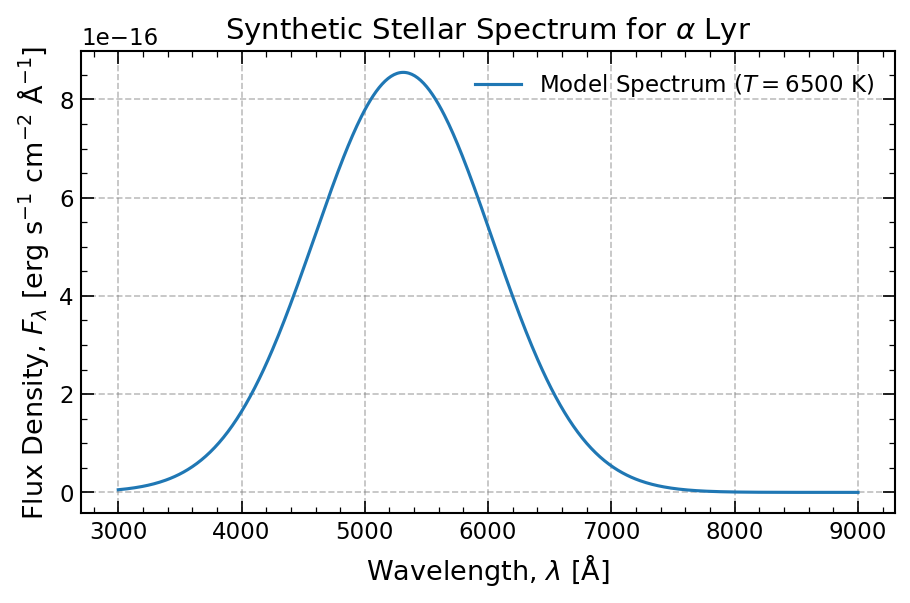

In [6]:
# Sample data representing a blackbody-like spectrum.
wavelength = np.linspace(3000, 9000, 500) # Angstroms.
flux = 1e-15 * (wavelength / 5000)**(-2) * np.exp(-((wavelength - 5500)/1000)**2)

# Make a plot.
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(wavelength, flux, label='Model Spectrum ($T = 6500\\text{ K}$)')

# Using LaTeX syntax for axis labels, units, and subscripts.
ax.set_xlabel(r'Wavelength, $\lambda$ [$\mathrm{\AA}$]')
ax.set_ylabel(r'Flux Density, $F_{\lambda}$ [$\mathrm{erg\ s^{-1}\ cm^{-2}\ \AA^{-1}}$]')
ax.set_title(r'Synthetic Stellar Spectrum for $\alpha$ Lyr')

ax.legend(frameon=False)
plt.show()


> **⚠️ Warning:**
> 
> Some of you may know that you can use f-strings in Python to get variables into your strings. You can do this in $\LaTeX$ too, but you have to be careful because the curly braces (`{` and `}`) are *also* $\LaTeX$ tools, so sometimes this causes issues. Typically you will use an fr-string and it will usually work, but sometimes when curly braces are required for $\LaTeX$, you might need to put in an extra curly brace around the variable. Alternatively, you can split the string up if possible or use the `format` string concatenation method. The below example will highlight this.

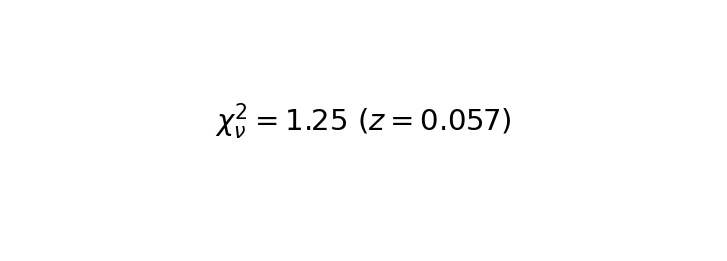

In [7]:
# A dynamic variable we want to display in our plot label.
chi2_val = 1.25
redshift = 0.057

# fr-string example: 
# Notice {{2}} and {{\nu}} stay as literal LaTeX, 
# while {{{chi2_val}}} evaluates our Python variable inside LaTeX braces.
label_fr = fr'$\chi^2_{{\nu}} = {{{chi2_val:.2f}}}$ ($z = {{{redshift:.3f}}}$)'

fig, ax = plt.subplots(figsize=(6, 2))
ax.text(0.5, 0.5, label_fr, fontsize=14, ha='center')
ax.axis('off')
plt.show()

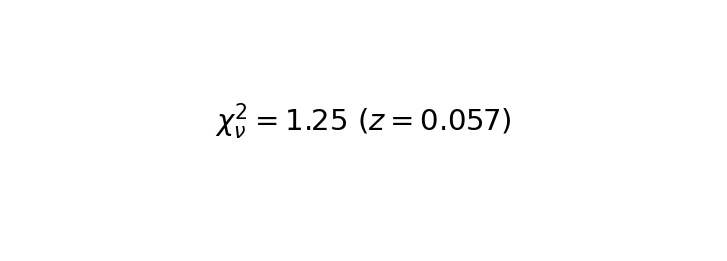

In [8]:
# Alternative: Pure LaTeX raw string combined with an f-string via concatenation.
label_concat = r'$\chi^2_{\nu} = $' + f'{chi2_val:.2f}' + r' ($z = $' + f'{redshift:.3f}' + r'$)$'

fig, ax = plt.subplots(figsize=(6, 2))
ax.text(0.5, 0.5, label_concat, fontsize=14, ha='center')
ax.axis('off')
plt.show()


[This video](https://www.youtube.com/watch?v=VR865ZdsQxs) provides a helpful visual walkthrough of how Python interprets single, double, and triple curly braces inside formatted string literals.

[![](https://markdown-videos-api.jorgenkh.no/youtube/VR865ZdsQxs)](https://youtu.be/VR865ZdsQxs)

___

## 4. Color Accessibility & Visual Encoding

Color is one of the most powerful tools in data visualization, but it is also easily misused. Beyond Color Vision Deficiency (CVD)—which affects ~8% of men and 0.5% of women—we must consider how colormaps map data to human perception and how figures survive grayscale printing.

### Pitfalls of Specific Colormap Types
1. **Cyclical Colormaps (e.g., `hsv`):** These loop back on themselves (red $\rightarrow$ green $\rightarrow$ blue $\rightarrow$ red). If used on sequential data (like temperature or density), the wrap-around creates a **false visual boundary** where none exists in the data. Only use cyclical colormaps for truly cyclic data (e.g., orbital phase, position angle, or RA/Dec right ascension coordinates).
2. **Diverging Colormaps (e.g., `coolwarm`, `bwr`):** Excellent for showing data that diverges from a critical center point (like residuals or velocity maps where $v = 0$). However, they **must** be symmetrically centered on your data's zero point; otherwise, they heavily bias perception.

### Redundant Encoding: Beyond Color Alone
To make multi-line or multi-scatter plots truly accessible (both for CVD readers and monochrome thesis prints), **never rely on color alone**. Combine color with:
- **Line Styles:** Solid (`-`), dashed (`--`), dotted (`:`), and dash-dot (`-.`).
- **Marker Shapes:** Circles (`o`), squares (`s`), triangles (`^`), and crosses (`x`).
- **Matplotlib's Built-in Palettes:** Use accessibility-checked defaults like Tableau's colorblind palette (`tableau-colorblind10`).


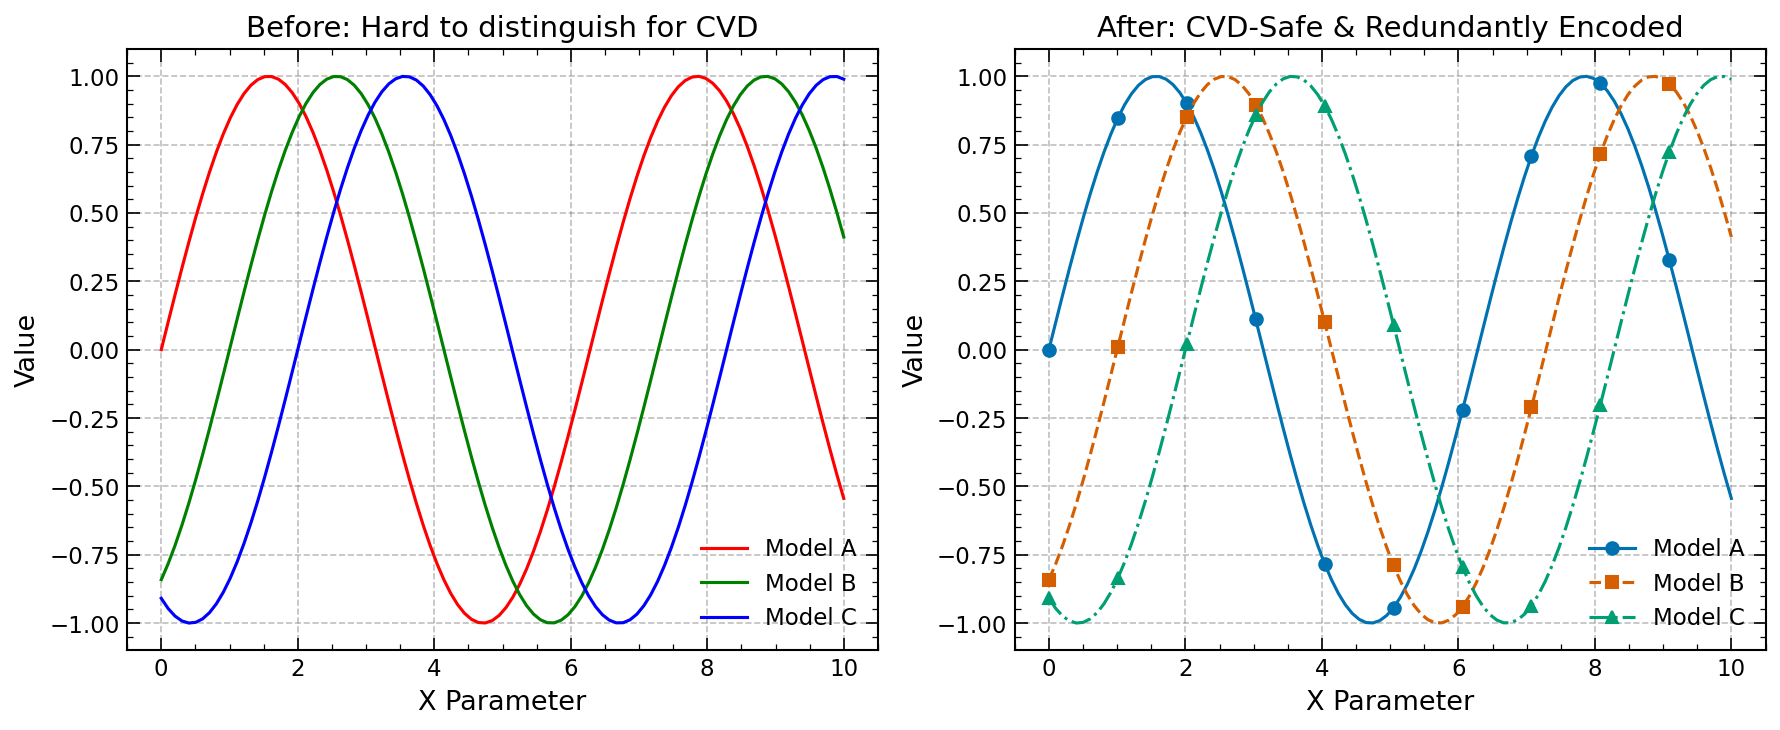

In [9]:
# Sample data for a multi-model comparison.
x = np.linspace(0, 10, 100)
y1 = np.sin(x)
y2 = np.sin(x - 1.0)
y3 = np.sin(x - 2.0)

fig, (ax_before, ax_after) = plt.subplots(1, 2, figsize=(12, 5))

# --------------------------------------------------------------------------------------
# ❌ BEFORE: Inaccessible (Relies on pure Red/Green/Blue, solid lines, no redundancies).
# --------------------------------------------------------------------------------------
ax_before.plot(x, y1, color='red', label='Model A')
ax_before.plot(x, y2, color='green', label='Model B')
ax_before.plot(x, y3, color='blue', label='Model C')

ax_before.set_title('Before: Hard to distinguish for CVD')
ax_before.set_xlabel('X Parameter')
ax_before.set_ylabel('Value')
ax_before.legend(frameon=False)


# ---------------------------------------------------------------
# ✅ AFTER: CVD-Friendly (Tableau colors + Line styles + Markers)
# ---------------------------------------------------------------
# Using Tableau colorblind palette colors explicitly.
# #0072B2 (Blue), #D55E00 (Vermillion/Orange), #009E73 (Bluish Green)
ax_after.plot(x, y1, color='#0072B2', linestyle='-', marker='o', markevery=10, label='Model A')
ax_after.plot(x, y2, color='#D55E00', linestyle='--', marker='s', markevery=10, label='Model B')
ax_after.plot(x, y3, color='#009E73', linestyle='-.', marker='^', markevery=10, label='Model C')

ax_after.set_title('After: CVD-Safe & Redundantly Encoded')
ax_after.set_xlabel('X Parameter')
ax_after.set_ylabel('Value')
ax_after.legend(frameon=False)

plt.tight_layout()
plt.show()


If you don't want to think about the colors themselves, you can always use `plt.style.use` and the default `tableau-colorblind10` so you don't need to explicitly state all the colors.

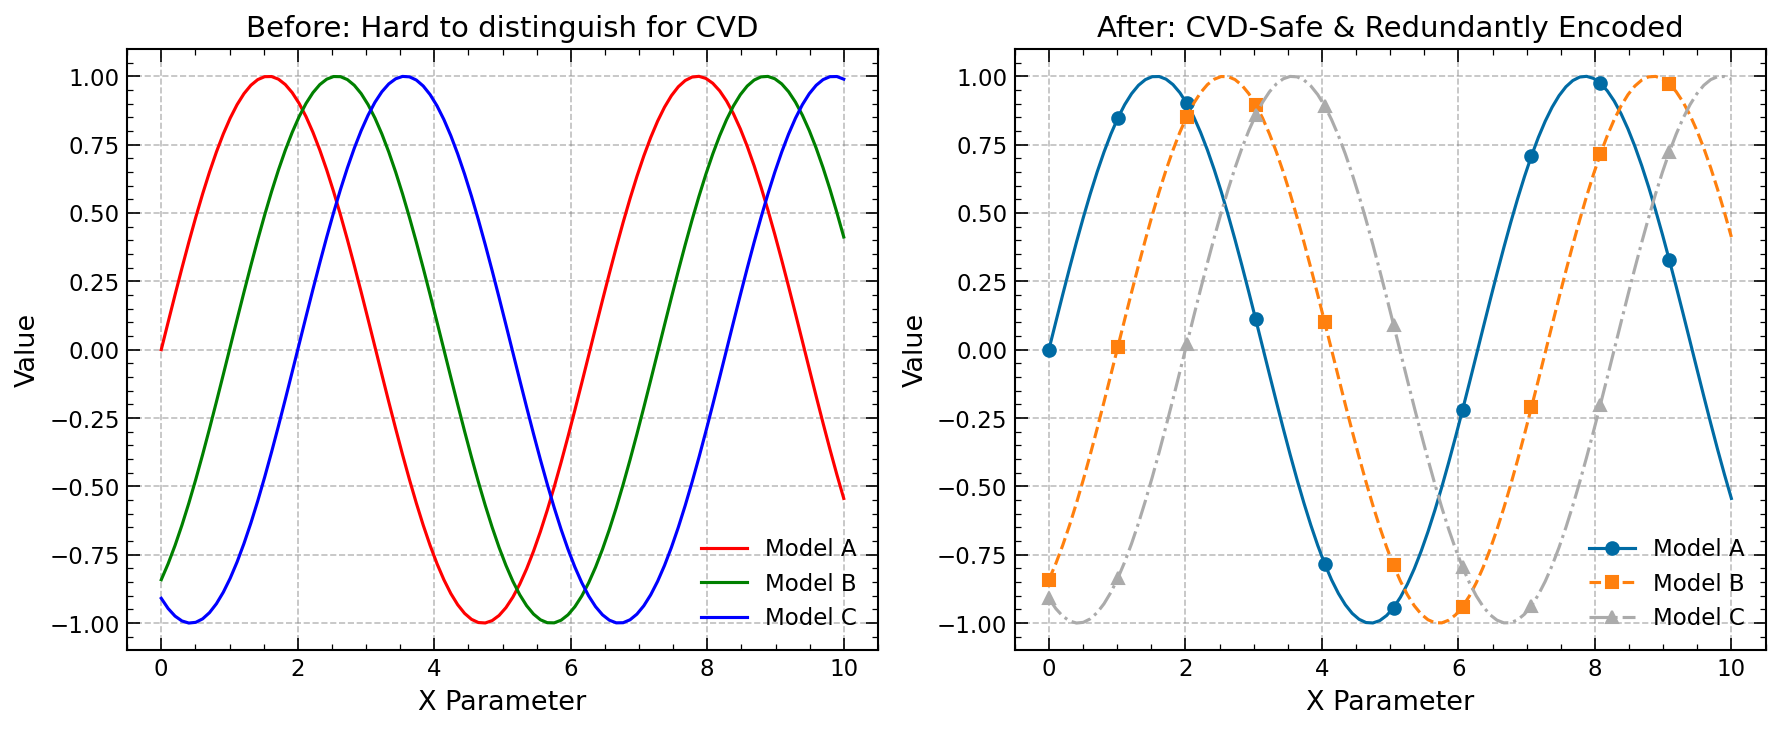

In [10]:
# Use the tableau-colorblind10 palette.
plt.style.use('tableau-colorblind10')

fig, (ax_before, ax_after) = plt.subplots(1, 2, figsize=(12, 5))

# --------------------------------------------------------------------------------------
# ❌ BEFORE: Inaccessible (Relies on pure Red/Green/Blue, solid lines, no redundancies).
# --------------------------------------------------------------------------------------
ax_before.plot(x, y1, color='red', label='Model A')
ax_before.plot(x, y2, color='green', label='Model B')
ax_before.plot(x, y3, color='blue', label='Model C')

ax_before.set_title('Before: Hard to distinguish for CVD')
ax_before.set_xlabel('X Parameter')
ax_before.set_ylabel('Value')
ax_before.legend(frameon=False)


# ---------------------------------------------------------------
# ✅ AFTER: CVD-Friendly (Tableau colors + Line styles + Markers)
# ---------------------------------------------------------------
# Using Tableau colorblind palette colors explicitly.
# ! Here we now let the plt.style.use deal with the colors.
ax_after.plot(x, y1, linestyle='-', marker='o', markevery=10, label='Model A')
ax_after.plot(x, y2, linestyle='--', marker='s', markevery=10, label='Model B')
ax_after.plot(x, y3, linestyle='-.', marker='^', markevery=10, label='Model C')

ax_after.set_title('After: CVD-Safe & Redundantly Encoded')
ax_after.set_xlabel('X Parameter')
ax_after.set_ylabel('Value')
ax_after.legend(frameon=False)

plt.tight_layout()
plt.show()


> 🎨 **Pro-Tip:** 
> 
> For discrete categorical data (like different stellar populations, galaxy morphologies, or instrument filters), use color palettes designed specifically for accessibility, such as **ColorBrewer** qualitative sets (`Set2`, `Dark2`) or the **Paul Tol** color schemes implemented in packages like `cmasher` or `palettable`.

Let's look at an example regarding 2D colormaps too.

When displaying continuous 2D data (like images, density maps, or temperature fields), the choice of colormap determines what features are visible—and what features are artificially created by the color scale itself.

A professional astronomy plot requires a **Perceptually Uniform, Sequential Colormap**:

1.  **Perceptually Uniform:** A fixed step in data value (e.g., $\Delta T = 100\text{ K}$) corresponds to an equal, consistent step in perceived color brightness and hue across the entire map. This prevents false artifacts (like the illusory "spikes" or "gradients" seen in non-uniform maps).
2.  **Sequential:** Colors progress smoothly from dark/low-value to bright/high-value, providing a intuitive hierarchy that translates perfectly to grayscale/monochrome printing.

I recommend aiming for the modern Matplotlib defaults (`viridis`, `magma`, `plasma`, `inferno`) or specialized astronomy palettes found in packages like `cmasher` or `palettable`.

> **⚠️ Warning:**
> 
> Careful with some of these packages like `cmasher`! Not all their color palletes are CVD-friendly!

#### Examples to Avoid/Embrace:

*   **⚠️ The 'Jet' Pitfall:** The traditional `jet` (or `rainbow`) colormap is notorious for being perceptually non-uniform. It has prominent "bands" of yellow and cyan that draw the eye toward specific data thresholds that don't actually exist, while effectively compressing and hiding real features in the saturated red and blue regions. It also vanishes completely when printed in black-and-white.
*   **⚠️ The 'Diverging' Pitfall:** Many diverging colormaps have their own pitfalls! They usually have their ends having the same brightness, so for those who see in grayscale, they cannot differentiate anything! On top of that, many include red and green colors which could be problematic for color vision deficiencies. An example of this is `matplotlib`'s `seismic` or `bwr` colormaps.
*   **✅ Perceptually Uniform (`magma`):** The `magma` colormap (part of the `viridis` family) provides a smooth, intuitive gradient from dark (low intensity) to bright (high intensity). It maximizes detail and remains readable even under extreme Color Vision Deficiency (CVD).

We'll take a look at an example of both of these pitfalls. First, the `jet` pitfall:

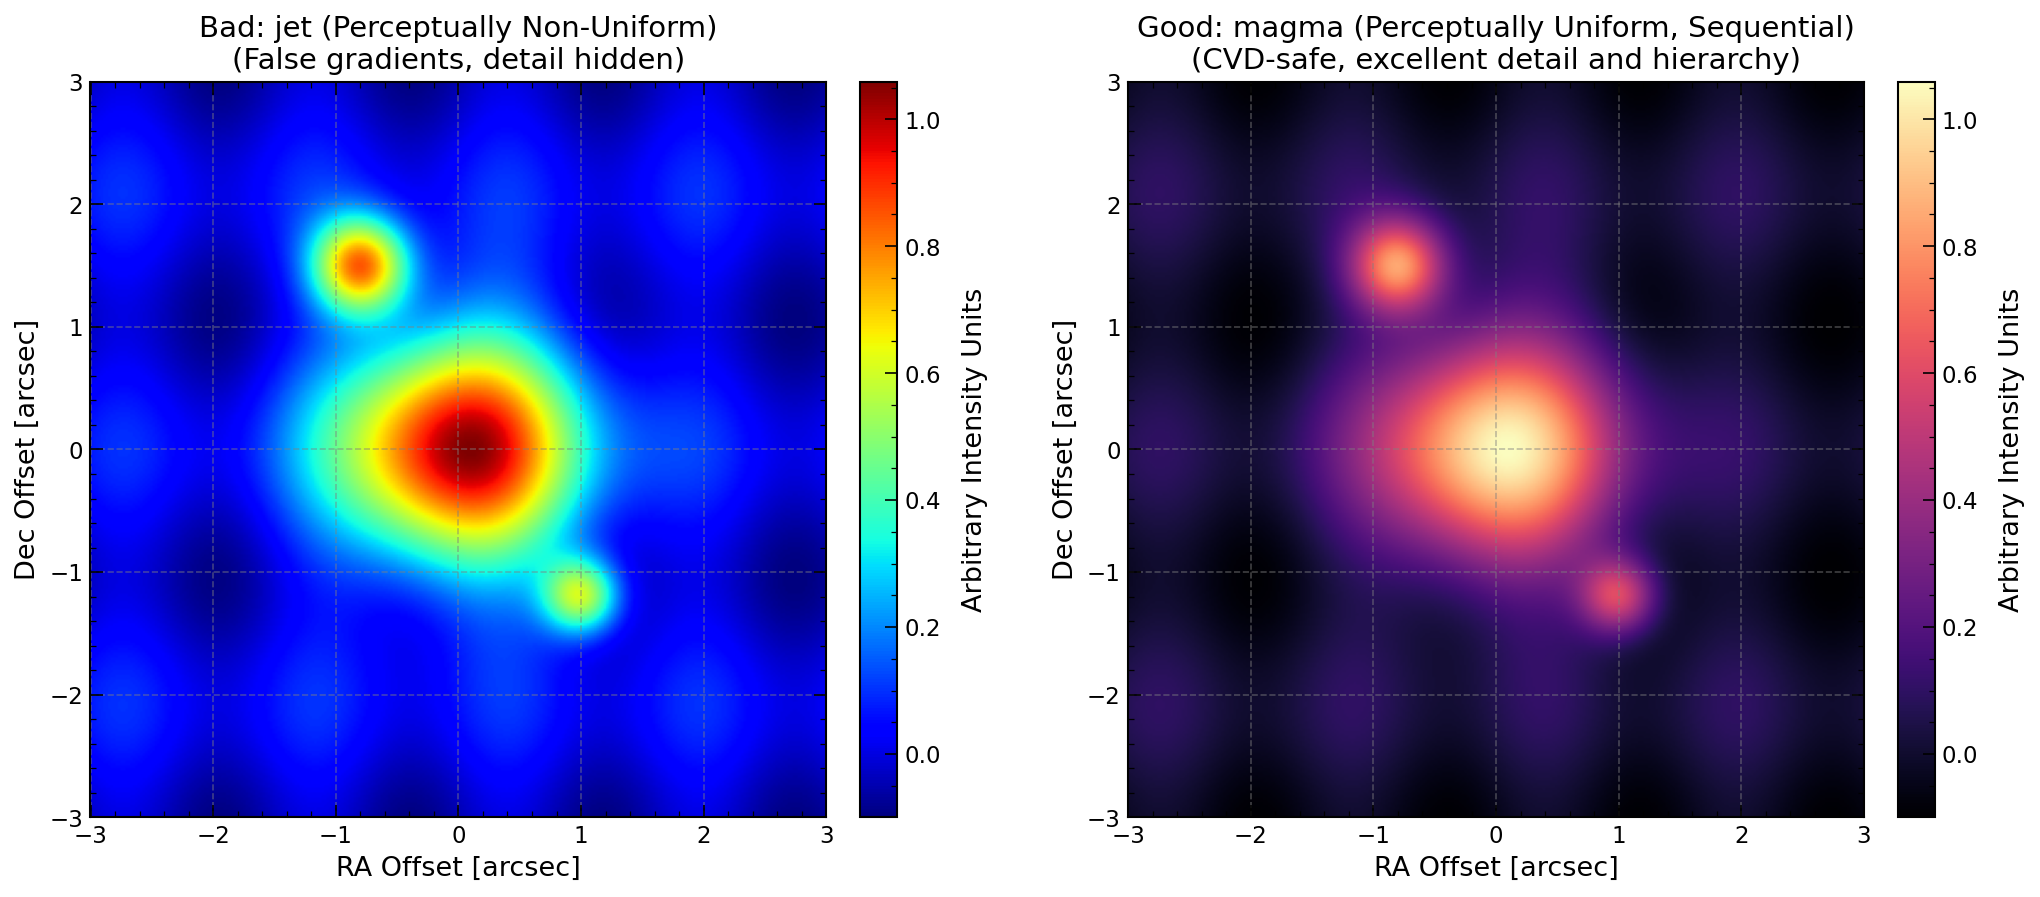

In [11]:
# Generate dynamic 2D data mimicking an astronomical source.
# A large Gaussian blob representing a diffuse source.
# Two smaller, brighter peaks representing embedded stars/compact cores.
# Subtle ripples of low-level structure.

def make_dummy_data(N):
    x = np.linspace(-3, 3, N)
    y = np.linspace(-3, 3, N)
    X, Y = np.meshgrid(x, y)
    
    # Large Gaussian.
    Z = np.exp(-(X**2 + Y**2)) 
    
    # Embedded compact cores.
    Z += 0.6 * np.exp(-((X - 1)**2 + (Y + 1.2)**2) / 0.1)
    Z += 0.8 * np.exp(-((X + 0.8)**2 + (Y - 1.5)**2) / 0.15)
    
    # Low-level subtle features/ripples.
    Z += 0.05 * (np.sin(X * 4) + np.cos(Y * 3))
    
    return X, Y, Z

X, Y, Z_data = make_dummy_data(300)

# Plot the comparison.
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ❌ Plot 1: BAD Colormap (`jet`).
im_bad = axes[0].imshow(Z_data, cmap='jet', extent=[-3, 3, -3, 3], origin='lower')
axes[0].set_title('Bad: jet (Perceptually Non-Uniform)\n(False gradients, detail hidden)')
axes[0].set_xlabel('RA Offset [arcsec]')
axes[0].set_ylabel('Dec Offset [arcsec]')
cbar_bad = fig.colorbar(im_bad, ax=axes[0], fraction=0.046, pad=0.04)
cbar_bad.set_label('Arbitrary Intensity Units', labelpad=10)


# ✅ Plot 2: GOOD Colormap (`magma`).
im_good = axes[1].imshow(Z_data, cmap='magma', extent=[-3, 3, -3, 3], origin='lower')
axes[1].set_title('Good: magma (Perceptually Uniform, Sequential)\n(CVD-safe, excellent detail and hierarchy)')
axes[1].set_xlabel('RA Offset [arcsec]')
axes[1].set_ylabel('Dec Offset [arcsec]')
cbar_good = fig.colorbar(im_good, ax=axes[1], fraction=0.046, pad=0.04)
cbar_good.set_label('Arbitrary Intensity Units', labelpad=10)

plt.tight_layout()
plt.show()


Now we'll take a look at the diverging colormap pitfall:

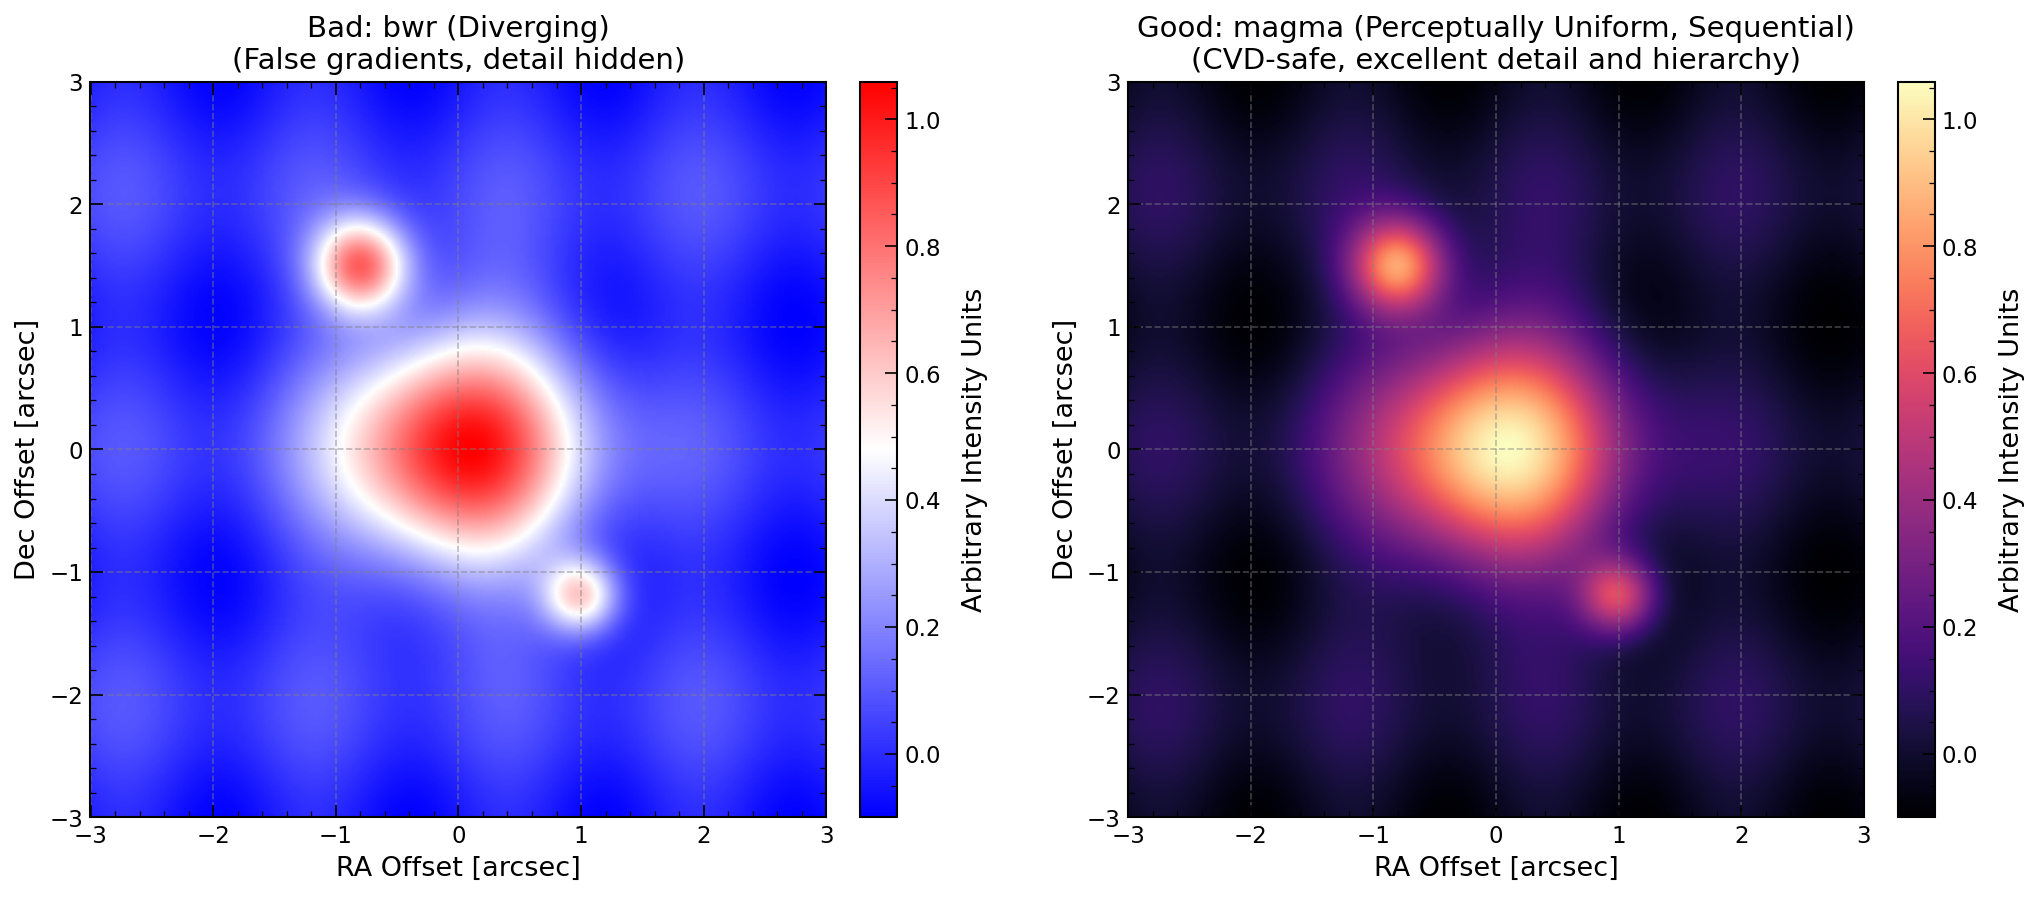

In [12]:
# Plot the comparison.
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ❌ Plot 1: BAD Colormap (`bwr`).
im_bad = axes[0].imshow(Z_data, cmap='bwr', extent=[-3, 3, -3, 3], origin='lower')
axes[0].set_title('Bad: bwr (Diverging)\n(False gradients, detail hidden)')
axes[0].set_xlabel('RA Offset [arcsec]')
axes[0].set_ylabel('Dec Offset [arcsec]')
cbar_bad = fig.colorbar(im_bad, ax=axes[0], fraction=0.046, pad=0.04)
cbar_bad.set_label('Arbitrary Intensity Units', labelpad=10)


# ✅ Plot 2: GOOD Colormap (`magma`).
im_good = axes[1].imshow(Z_data, cmap='magma', extent=[-3, 3, -3, 3], origin='lower')
axes[1].set_title('Good: magma (Perceptually Uniform, Sequential)\n(CVD-safe, excellent detail and hierarchy)')
axes[1].set_xlabel('RA Offset [arcsec]')
axes[1].set_ylabel('Dec Offset [arcsec]')
cbar_good = fig.colorbar(im_good, ax=axes[1], fraction=0.046, pad=0.04)
cbar_good.set_label('Arbitrary Intensity Units', labelpad=10)

plt.tight_layout()
plt.show()


For both of these, for a normal vision user, these may not seem to be an issue. But for color vision deficiencies, the left-hand panels of these plots could cause major struggles in understanding!

Why don't we take a look?

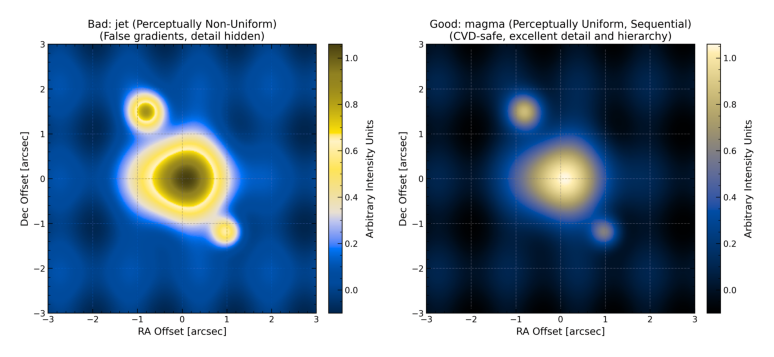

In [13]:
# Read a pre-made image on why these colormaps are bad.
img_array = plt.imread('heatmap_jet_bad.png')

fig, ax = plt.subplots()

# Display the image using imshow.
ax.imshow(img_array, origin='upper')
ax.axis('off') 

plt.show()

The above image is the `jet` and `magma` colormaps for those with red-green colorblindness (Protanopia). We can see this issue of perceptually non-uniformity. The left plot is not a smooth decrease to increase in brightness, which causes issues in false gradients. Also some of the colors repeat mildly (that white-ish color), which makes it harder to analyze the image. The `magma` colormap on the right-hand side is just as clear to analyze as it is for standard color vision.

Now let's see the diverging issue:

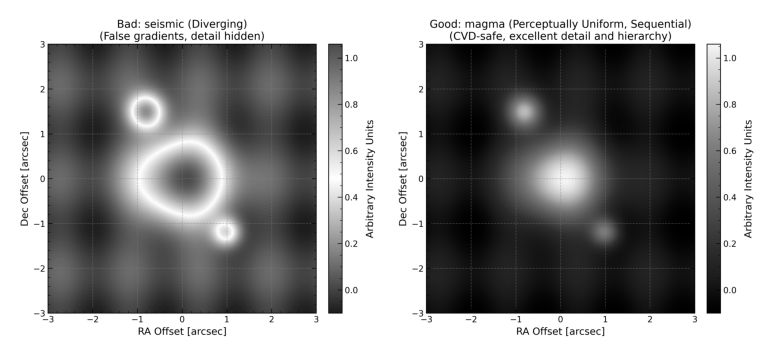

In [14]:
# Read a pre-made image on why these colormaps are bad.
img_array = plt.imread('heatmap_diverging_bad.png')

fig, ax = plt.subplots()

# Display the image using imshow.
ax.imshow(img_array, origin='upper')
ax.axis('off') 

plt.show()

For those with grayscale vision, the problem with the divergent colormap is apparent. The divergent nature means the center of the colorbar upwards and the center of the colorbars downward are *identical*. So any of those light gray values, can you honestly say if they're 0.2 or 0.8? Can you tell if the center of the big blob is closer to 0.0 or 1.0? On the right hand side, due to the sequential, perceptually uniform nature, we can clearly see what those background values are, and we can clearly see the center of the big blob is closer to 1.0.

#### 🔭 Where to Find Good Colormaps

1.  **Matplotlib's Perceptually Uniform Palettes:** `viridis` (default), `magma`, `plasma`, `inferno`, `cividis` (specifically optimized for CVD).
2.  **`cmasher`:** A dedicated Python package (`pip install cmasher`) that provides a vast suite of rigorous, perceptually uniform colormaps often tailored for astronomical contexts (e.g., `cmr.horizon`, `cmr.cosmic`, `cmr.ember`).
3.  **`palettable`:** Another package with many color schemes, including the famous ColorBrewer sets and scientific palettes like those by Paul Tol.

Now you might be asking how to know if your plot looks good for different color vision deficiencies and how I got these images. Some operating systems (like MacOS) have color vision filters in their system settings which you can use, but for general usage, I use a color blindness simulator. The most common one is the [Coblis Color Blindess Simulator](https://www.color-blindness.com/coblis-color-blindness-simulator/). It allows you to upload an image and select different color vision deficiencies (anomalous, dichromatic, and monochromatic). A good general rule of thumb is that your plot looks good for **all** of these options. 

You can also open the image in a new window, which helps viewing better because the view window reduces your image resolution. 

Below is what the UI looks like:

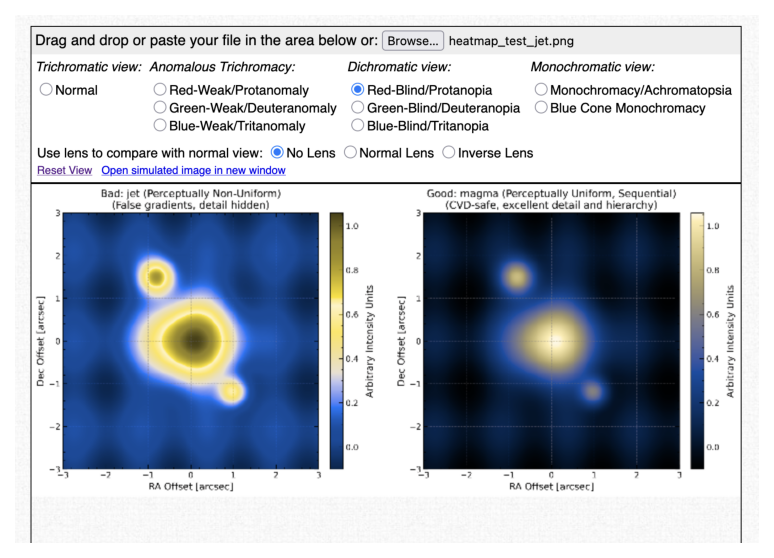

In [15]:
# UI image.
img_array = plt.imread('coblis.png')

fig, ax = plt.subplots()

# Display the image using imshow.
ax.imshow(img_array, origin='upper')
ax.axis('off') 

plt.show()

___

## 5. Advanced Astronomical Plot Conventions

Beyond basic styles and colors, astronomy relies on several unique graphical conventions to handle real observational data, such as magnitude scales, non-detections, massive data gaps, and multi-panel layouts. 

Here are the **five essential layout conventions** every astronomer should master (feel free to suggest more we can add later):

1. **Inverted Magnitude Axes (CMDs):** Because smaller numbers mean brighter objects, Color-Magnitude Diagrams must always invert their y-axes.
2. **Secondary/Dual Axes:** Displaying physical relationships simultaneously (e.g., Wavelength vs. Frequency or Wavelength vs. Redshift).
3. **Upper Limits & Non-Detections:** Using downward-pointing arrows (`uplims=True`) for sources below the sensitivity limit rather than hiding or misrepresenting them as real points.
4. **Multi-Panel Layouts (`GridSpec`):** Aligning companion plots (like a spectrum on top and a velocity residual map on the bottom) sharing a common axis.
5. **Broken Axes (Scale Breaks):** Handling massive dead zones or data gaps without wasting whitespace.


### I. & II. Inverted Axes and Dual Axes

First we take a look at inverting axes and using dual axes.

To invert axes, you can use the `matplotlib` axis commands `invert_yaxis` or `invert_xaxis`. 

To use a secondary axis, you can use the `secondary_xaxis` or `secondary_yaxis` function. This function returns an axis instance, so you can use that returned axis to set the label of that axis (etc.). We show that too. This function takes in a keyword argument `functions` in which you pass in a tuple of two functions. The easy way to remember it is that the first function in the tuple is how to get from your current x-axis to the new one (what transformation) and the second one is how to get from the transformed x-axis back to the original one. There are also ways to manually set the ticks of the upper axis instead of using that function, but we do not dicuss that here.

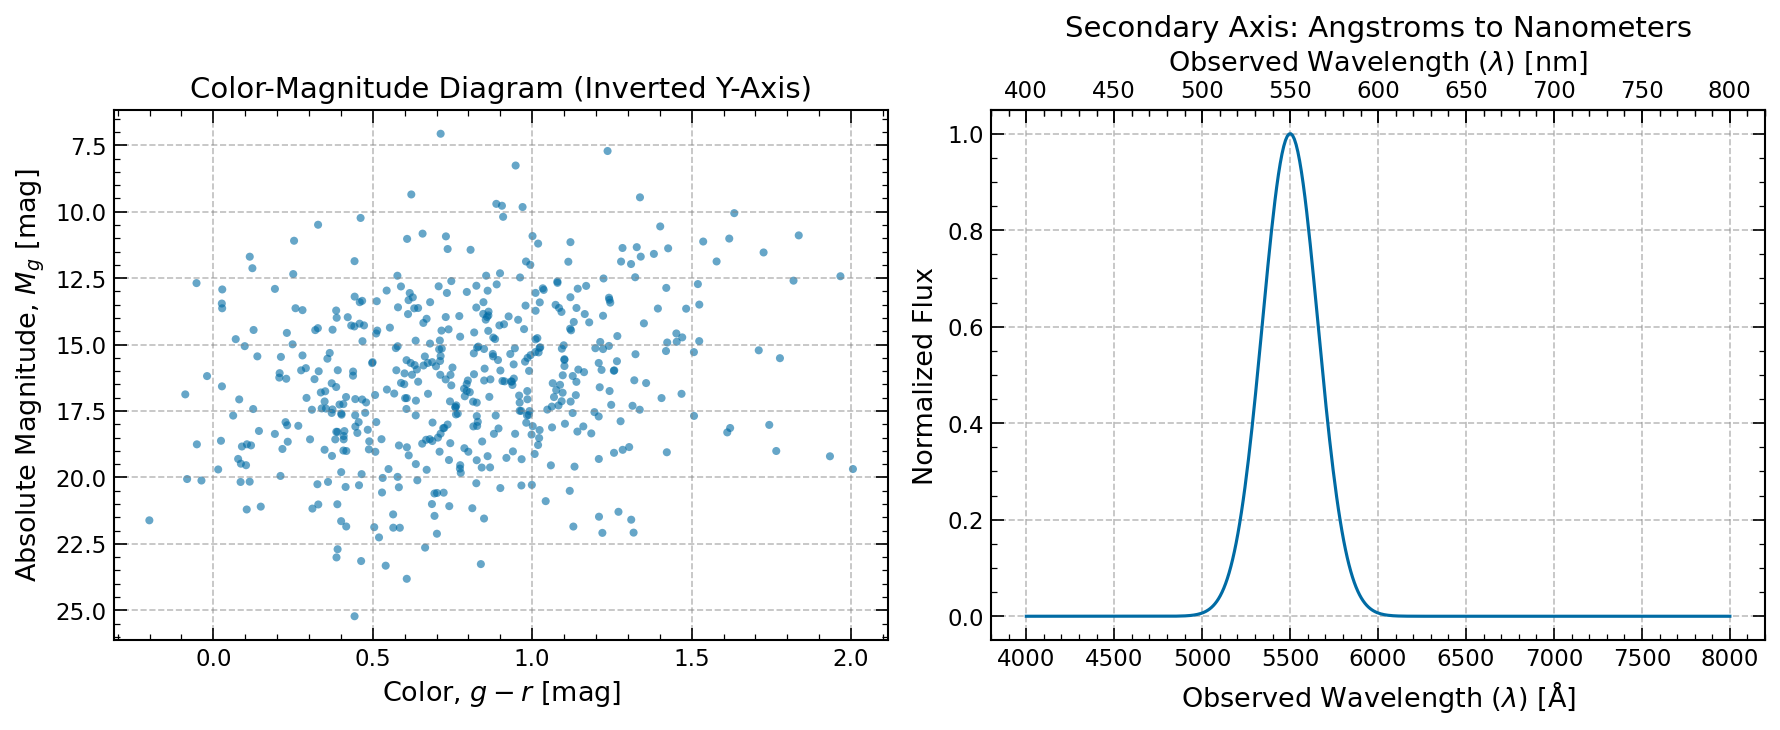

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Color-Magnitude Diagram (CMD) with an Inverted Y-Axis.
# We make some random normal points.
color_gp_r = np.random.normal(0.8, 0.4, 500)
magnitude_g = np.random.normal(18, 3, 500) - 2 * color_gp_r

ax1.scatter(color_gp_r, magnitude_g, alpha=0.6, s=15, edgecolors='none', rasterized=True)
ax1.invert_yaxis()  # Bright objects at the top.

ax1.set_xlabel(r'Color, $g - r$ [mag]')
ax1.set_ylabel(r'Absolute Magnitude, $M_g$ [mag]')
ax1.set_title('Color-Magnitude Diagram (Inverted Y-Axis)')

# Spectrum with a Secondary X-Axis (Angstroms vs. Nanometers).
# Generate some wavelength and flux data.
wave_angstroms = np.linspace(4000, 8000, 400)
flux = np.exp(-((wave_angstroms - 5500)**2) / 50000)

ax2.plot(wave_angstroms, flux, lw=1.5)
ax2.set_xlabel(r'Observed Wavelength ($\lambda$) [$\mathrm{\AA}$]')
ax2.set_ylabel(r'Normalized Flux')
ax2.set_title('Secondary Axis: Angstroms to Nanometers')

# Clean, linear conversion functions.
# These should avoid divide-by-zero warnigns too.
def ang_to_nm(wave_ang):
    return wave_ang / 10.0

def nm_to_ang(wave_nm):
    return wave_nm * 10.0

# Create the secondary top axis.
secax = ax2.secondary_xaxis('top', functions=(ang_to_nm, nm_to_ang))
secax.set_xlabel(r'Observed Wavelength ($\lambda$) [nm]')

plt.tight_layout()
plt.show()


### III. Handling Non-Detections

In astronomy, when a telescope looks at a faint source (like a distant galaxy), the data is always accompanied by instrument and background noise. 
* **Detection:** If the signal is strong enough compared to the noise, we measure a clear value (with an error bar).
* **Non-Detection (Upper Limit):** If the object is too faint to rise above the noise floor, we **cannot** just say its flux is zero or ignore it. Saying it's zero is physically wrong because our telescope still collected *some* light. Instead we report an **upper limit**, meaning: "We didn't detect the source here, but based on our noise level, we can guarantee it is fainter than this threshold value, since we still collected this measured flux value without detecting the source in question."

You use upper limits whenever you are tracking objects that change brightness over time (variable stars, gamma-ray bursts, transient events) or looking for very faint populations.

For example, if a supernova fades over 5 weeks, the first 3 weeks might be clear detections, but the final 2 weeks might drop below the telescope's sensitivity limit, becoming non-detections. You still need to plot those late-stage non-detections to show modelers that the supernova dropped below a certain brightness level by week 4.

We show this as a crude example below:

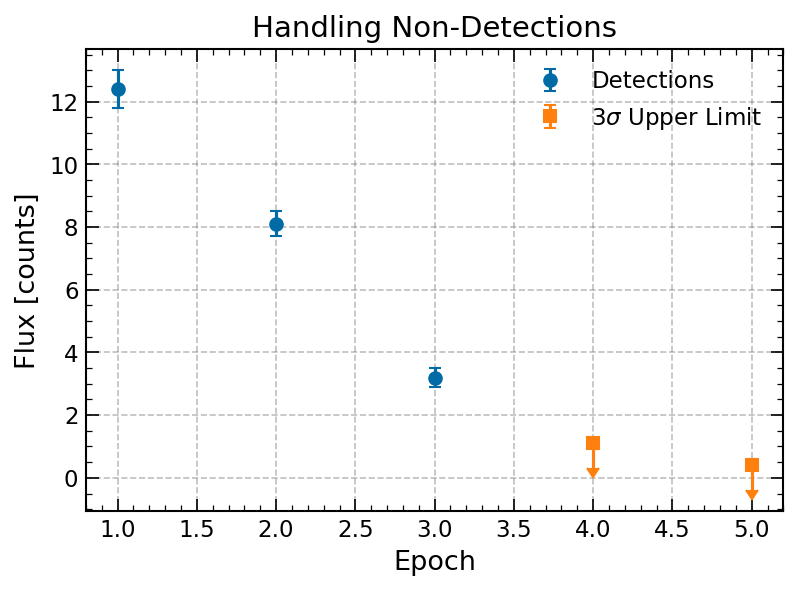

In [26]:
# Generate some random flux data.
x = np.array([1, 2, 3, 4, 5])
flux = np.array([12.4, 8.1, 3.2, 1.1, 0.4])
yerr = np.array([0.6, 0.4, 0.3, 0.2, 0.2])

# These are the "upper limits".
# We say that the first three are detections and the last two are not.
upper_limits = np.array([False, False, False, True, True])

fig, ax = plt.subplots(figsize=(6, 4))

# Real measurements.
# The ~ helps reverse the upper_limits values. 
ax.errorbar(x[~upper_limits], flux[~upper_limits], yerr=yerr[~upper_limits], 
            fmt='o', label='Detections', capsize=3)

# Non-detections (Upper Limits).
ax.errorbar(x[upper_limits], flux[upper_limits], yerr=0.8, 
            fmt='s', uplims=True, label='3$\\sigma$ Upper Limit', capsize=3)

ax.set_xlabel('Epoch')
ax.set_ylabel('Flux [counts]')
ax.set_title('Handling Non-Detections')
ax.legend(frameon=False)
plt.show()


Let's talk about this in more detail so this makes sense.

First, we have a *boolean mask*: `upper_limits`. Wherever this is `True`, we are saying that this is a non-detection or upper limit. `False` means it is a genuine detection. 

We then plot the detections:
```py
ax.errorbar(x[~upper_limits], flux[~upper_limits], yerr=yerr[~upper_limits], 
            fmt='o', label='Detections', capsize=3)
```

The `~upper_limits` reverses the values in the boolean mask. This means any value that is `True` becomes `False` and vice versa. So, this is a way to use Python's slicing to say that: "anything that is *not* and upper limit (value=`False`), plot these."

We use `fmt='o'` to plot these as circles, with their error bars. 

We then plot the upper-limits:
```py
ax.errorbar(x[upper_limits], flux[upper_limits], yerr=0.8, 
            fmt='s', uplims=True, label='3$\\sigma$ Upper Limit', capsize=3)
```

We don't need to reverse the boolean mask here, because wherever the value in the mask is `True` *is* an upper limit, and we only want to plot those. **We use redundancy here, plotting these as squares and a different color!** The keyword argument `uplims=True` tells `matplotlib` to draw a *downward-pointing arrow* starting from the point value, visually communication to the reader: "The actual value isn't here; It's somewhere underneath this arrow."

> ### 🔭 Important Note: Handling Non-Detections & Upper Limits
> 
> When plotting non-detections (upper limits) using `uplims=True`, we typically use a uniform noise threshold (such as a $3\sigma$ sensitivity limit) rather than the individual measurement errors:
> 
> *   **Measuring Sensitivity:** For a non-detection, you aren't measuring an object's actual brightness; you are quantifying the background noise floor of the telescope at that moment.
> *   **Controlling Arrow Length:** Matplotlib uses the `yerr` value to determine the size of the downward arrow. Using a consistent value keeps your upper limit arrows clean and visually uniform.
>
> That is why, even though we have values of the y-error in our `yerr` array from earlier for the upper limits, we use a different value of `yerr=0.8` in the `ax.errorbar` call. The new value basically tells `matplotlib`: "Draw the limit arrow based on the $3\sigma$ noise floor, which is 0.8 for both non-detections, not whatever `yerr` we measured, because 0.8 is the actual boundary below which we can't reliably detect the source."


### IV. Multi-Panel Layouts

Now let's take a look at making multi-panel plots. But we don't mean the standard `plt.subplots` model. I mean, sharing axes so plots can be directly side-by-side. This is great for residuals and to keep a tighter, cleaner plot layout:

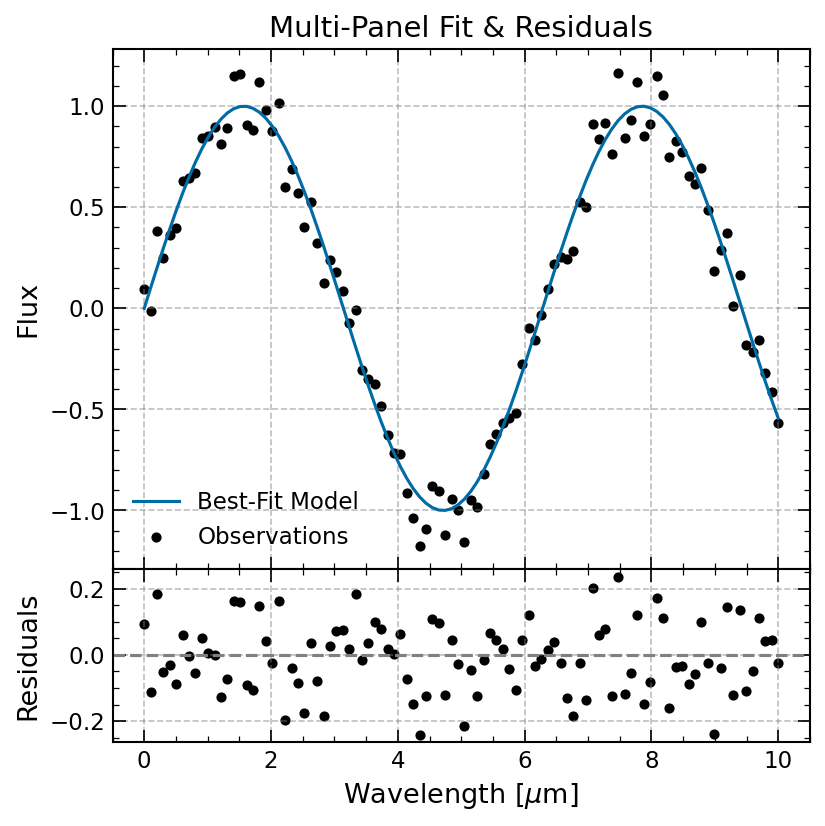

In [18]:
# Generate a sine curve with some random normal noise.
x = np.linspace(0, 10, 100)
y_model = np.sin(x)
y_data = y_model + np.random.normal(0, 0.1, 100)
residuals = y_data - y_model

# Create a figure with shared x-axis and unequal heights (top panel bigger).
fig, (ax_data, ax_res) = plt.subplots(2, 1, figsize=(6, 6), sharex=True, 
                                      gridspec_kw={'height_ratios': [3, 1]})

# Top Panel: Data vs Model.
ax_data.plot(x, y_model, label='Best-Fit Model')
ax_data.scatter(x, y_data, color='black', s=15, label='Observations')
ax_data.set_ylabel('Flux')
ax_data.legend(frameon=False)
ax_data.set_title('Multi-Panel Fit & Residuals')

# Bottom Panel: Residuals.
ax_res.axhline(0, color='gray', linestyle='--')
ax_res.scatter(x, residuals, color='black', s=15)
ax_res.set_xlabel('Wavelength [$\\mu$m]')
ax_res.set_ylabel('Residuals')

# Remove gap between subplots.
fig.subplots_adjust(hspace=0)
plt.show()


There are a few keys to this.

To physically ensure that the axes are shared, you pass in this information to `plt.subplots`. To share the x-axis, you pass in `sharex=True` (`sharey=True` respectively). The `gridspec_kw` argument allows us to control the height ratios of the different plots. By default, `matplotlib` will make both aspect ratios the same. By passing in `[3, 1]`, we force `matplotlib` to make sure that the top plot is 3x bigger than the bottom in height aspect ratio.

Now, in the above example so far, what you've done is told `matplotlib` that both x-axes should be shared, and that their height aspect ratios are 3:1, but you *haven't* told `matplotlib` to physically put the plots together. That's what the line `plt.subplots_adjust(hspace=0)` enforces (try commenting it and look what happens!). By calling that function, `matplotlib` now knows that it should put the plots with no space relative to each other.

### V. Broken Axes

Finally, let's look at breaking the axes:

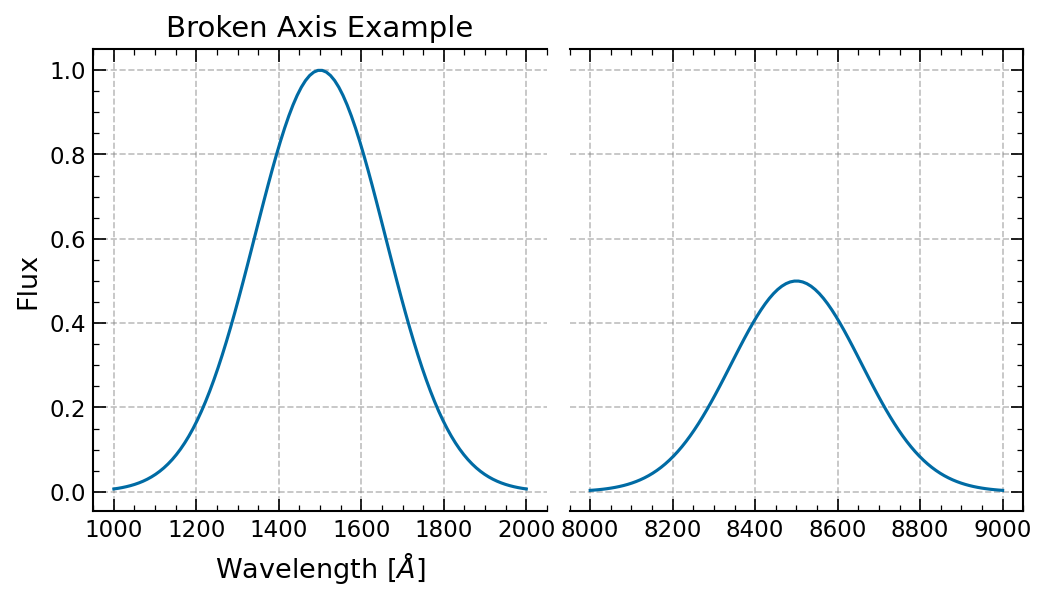

In [19]:
# Data with a huge empty gap in the middle (e.g., missing wavelength range).
x1 = np.linspace(1000, 2000, 100)
y1 = np.exp(-((x1-1500)**2)/50000)

x2 = np.linspace(8000, 9000, 100)
y2 = 0.5 * np.exp(-((x2-8500)**2)/50000)

fig, (ax1, ax2) = plt.subplots(1, 2, sharey=True, figsize=(8, 4))

# Plot left and right segments.
ax1.plot(x1, y1)
ax2.plot(x2, y2)

# Hide spines between them to create the "break" effect.
ax1.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax1.yaxis.tick_left()
ax2.yaxis.tick_right()
ax2.tick_params(labelright=False)

ax1.set_title('Broken Axis Example')
ax1.set_xlabel('Wavelength [$\\AA$]')
ax1.set_ylabel('Flux')

plt.subplots_adjust(wspace=0.05)
plt.show()


There's a lot to this, so let's take a look line-by-line.

So first, to make any sort of scale break, you need to trick `matplotlib`. You do this by using two subplots such that you can plot on each half. We can actually use the `sharey` from the previous step to ensure the y-axis is fixed for both plots. Here, I have physically unpacked the axes into `ax1` and `ax2` for clarity, but you can use the typical axis handling like below:
```py
fig, ax = plt.subplots(1, 2, sharey=True, figsize=(8, 4))

ax[0].plot(x1, y1)
ax[1].plot(x2, y2)

# ... etc. 
```

Then we plot the first half of the data on `ax1` and the second half on `ax2`. 


> **⚠️ Warning:**
> 
> You should note that you might need to specify the colors of the lines because you are technically working on two separate subplots. In this case, we don't need to, because both subplots default to displaying the `tableau` blue color as the first line, but this may become important if you have multiple lines. 

Then the next few lines are where the magic happens, getting the so-called "broken tick" effect:
```py
ax1.spines['right'].set_visible(False)  # This makes the right-side border axis of our left subplot no longer visible.
ax2.spines['left'].set_visible(False)   # This does the same, but for the left-side border of right subplot.
ax1.yaxis.tick_left()                   # This removes the ticks from the right-hand side of the left subplot ("tick only on the left side = tick_left").
ax2.yaxis.tick_right()                  # This does the same, but removes the left-side ticks from the right subplot.
ax2.tick_params(labelright=False)       # Ensures the right subplot has no tick labels on the right axis (doesn't really do anything in our case, but important to note).
```

Finally, the line with `plt.subplots_adjust(wspace=0.05)` helps decrease the width between the two subplots to bring them closer, so they're not so far apart by default.

___

## 6. Exporting & Journal Submission

Once your plot is styled, colored, and labeled, it’s time to save it for a publication, thesis, or presentation. Major astronomy journals (like *ApJ*, *A&A*, and *MNRAS*) have strict guidelines for digital figures. 

### Best Practices for Saving Figures:
1.  **Always use Vector Formats (`.pdf` or `.eps`):** Unlike raster formats (`.png` or `.jpg`), vector files store lines and text as geometric paths. This means an editor or reader can zoom in infinitely without the text or axis labels becoming pixelated.
2.  **Use `bbox_inches='tight'`:** By default, Matplotlib can clip axis labels, superscripts, or colorbar titles if they fall outside the standard figure boundary. `bbox_inches='tight'` automatically recalculates the bounding box before saving.
3.  **Selective Rasterization for Heavy Datasets:** If your scatter plot contains $10^5$ stars or particle simulation points, saving it as a pure vector PDF will generate a massive file that freezes PDF viewers. Instead, pass `rasterized=True` to the heavy scatter plot artist so only the dots become a high-resolution raster image, while your text, axes, and lines remain crisp vectors.


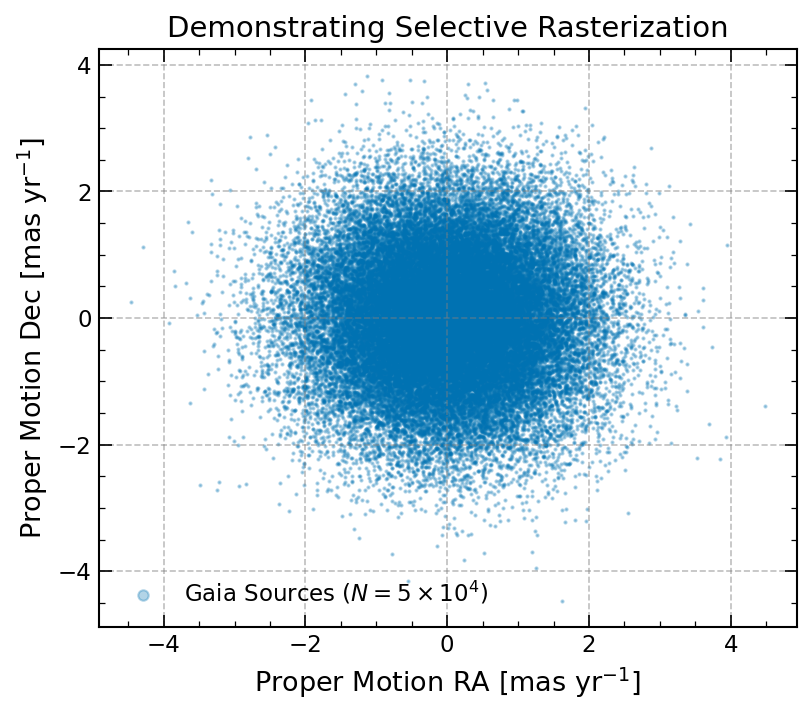

CPU times: user 1.26 s, sys: 76.1 ms, total: 1.34 s
Wall time: 1.39 s


In [20]:
%%time
# Time this notebook cell (above).

# Generate heavy dataset example (e.g., 50,000 stellar points).
np.random.seed(42)
x_heavy = np.random.normal(0, 1, 50000)
y_heavy = np.random.normal(0, 1, 50000)

fig, ax = plt.subplots(figsize=(6, 5))

# rasterized=True keeps the file size small and preview responsive.
ax.scatter(x_heavy, y_heavy, s=1.0, color='#0072B2', alpha=0.3, rasterized=True, label=r'Gaia Sources ($N=5\times 10^4$)')

ax.set_xlabel(r'Proper Motion RA [mas $\text{yr}^{-1}$]')
ax.set_ylabel(r'Proper Motion Dec [mas $\text{yr}^{-1}$]')
ax.set_title('Demonstrating Selective Rasterization')
ax.legend(frameon=False, markerscale=5)  # Scale legend marker up so it's visible.

# Saving the figure.
filename = 'professional_astronomy_plot.pdf'
plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.show()


So to explain this a little better, when plotting something (like in `ax.scatter`), you can use the keyword argument `rasterized=True` to make a rasterized image.

When you put in `rasterized=True` to a specific artist like `ax.scatter`, you effectively tell `matplotlib`: "Keep the axes, labels, and text as sharp vectors, but flatten these $N$ dots (50,000) into a high-resolution bitmap (*raster*) image."

> ### 💡 Possible Confusion: "Raster Formats" vs. "Rasterized Elements"
> 
> It’s easy to get turned around by the terminology here:
> 
> *   **Raster Formats (`.png`, `.jpg`):** These are **standalone file formats** where the *entire image* is stored as a grid of pixels (a bitmap). If you zoom in too far, you see the individual pixels.
> *   **`rasterized=True` (Inside a PDF):** Here, "rasterized" is a verb. It means taking a specific element (like 50,000 scatter points) and **converting them into a pixel grid/bitmap** *temporarily* so they can be embedded inside a vector document (`.pdf`). 
> 
> **In short:** `.png` and `.jpg` are *files* made entirely of pixels. `rasterized=True` is a tool that turns a heavy plot layer into pixels *inside* an otherwise scalable vector file!

Sometimes this helps increase the speed of making the plot (not usually a noticeable difference with modern laptop compute power), but more noticably it helps regulate your file sizes and your image viewing. Your PDF file size will balloon to huge values because without `rasterized=True`, it is storing raw vector data for 50,000 (or more) points. When you or a journal editor open that PDF image and try to scroll, zoom in, or view it, your PDF reader (Adobe Acrobat, Previer, your browser, etc.) will **freeze, lag, or crash**. This is because in the standard format, your viewer has to render tens of thousands of overlapping vector circles, straining the PDF viewer heavily. 

> ### 💡 Possible Confusion: Vector Files vs. Rasterized Elements
> 
> It is easy to mix up **file-level formats** and **object-level settings**:
> 
> *   **The File Format (`.pdf`):** When you save your overall figure as a PDF, the **file itself is a vector container**. This means your axes lines, tick numbers, and text labels are pure mathematical paths that will never pixelate, no matter how far you zoom in.
> *   **The `rasterized=True` Setting:** Because PDFs can handle mixed media, adding `rasterized=True` to a heavy scatter plot tells Matplotlib: *"Flatten *just these data points* into a high-resolution pixel grid so my PDF reader doesn't lag when scrolling, but keep all the surrounding text and axes as crisp vectors."*
> 
> **In short:** You are still saving a vector file (`.pdf`), you are just optimizing a heavy element *inside* of it!

If your compute power allows this, you can run the same test I ran. You can run for more points, like 1,000,000. 

| Rasterized? | CPU Wall Time Used | File Size |
| :--- | :--- | :--- |
| No | 14.1s | 7.7MB |
| Yes | 9.94s | 279KB |

The difference is clear! Imagine this for even more points! Imagine this for more than one plot!

We also include the other tips we discussed earlier (using `bbox_inches='tight'` and using a better format like `.pdf`) in the following lines:
```py
filename = 'professional_astronomy_plot.pdf'
plt.savefig(filename, dpi=300, bbox_inches='tight')
```

The `dpi` keyword allows for more dots per inch. This prevents your plot from ending up grainy, fuzzy, or low-resolution. You can tweak this, but I have (anectodally) found that a DPI of 300 is sufficient for almost all purposes.


---

## 🎉 Conclusion & Next Steps

You’ve now built a solid foundation for transforming basic functional code into professional, publication-ready astronomy figures! By implementing global `rcParams`, using built-in MathText for clean typography, prioritizing color accessibility (CVD-safety), handling astronomical conventions like inverted axes, and exporting clean vector files, your figures will stand out in any paper or thesis chapter.

### Have Ideas or Edits?
This notebook is a living document! If you discover new formatting tricks, encounter edge cases with specific telescope data formats, or want to suggest additions, contributions and feedback are always welcome. 

*Happy plotting, and clear skies!* 🔭✨
